# Coursework Set Week 5

**Common remarks**:

* Deadline: Sunday at 23:59h for the scheduled week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Tamara Balvin
* Username: tbalvin
* Student number: S6217451
* Group (AS1, etc.): AS1

-----

In [1]:
totalpoints = currentpoints = 0

### Plotting a galaxy rotation curve from data in a text file (4 pt) <font color='red'><b>COURSEWORK</b></font>

This qustion you will use data from an observation of NGC 6946. The stellar mass of NGC 6946 is $M_* = 2\times10^{10} M_{\odot}$, where $M_{\odot}$ represent *solar mass (the mass of the Sun)*. 

* Copy/download the file [rotcur.dat](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/rotcur.dat). This text file contains the output of a program that calculates rotation curves. Examine its contents on the Linux command line with a pager like ``more`` or in an editor so that you know what the columns represent.
* Write a program, that reads the columns `radius` and `rotation velocity`. Radii are in **kpc** and velocities in **km/s**.
* Create a line plot where the $x$-axis represents the radius and the $y$-axis represents the rotation velocity.
* Calculate the Keplerian rotation curve using $v=\sqrt{\frac{GM}{r}}$
* Create and save a text file called ``keplerian_curve.txt`` using ``np.savetxt()``.
* Using ``np.loadtxt()`` to load your Keplerian curve and plot it together with the observation data.
* Force the lower limit of the $y$-axis range to 0 and the upper limit to maximal values of the Keplerian curve.
* Annotate the plot with relevant information.
* Make comment about your observation.

**Answers**:

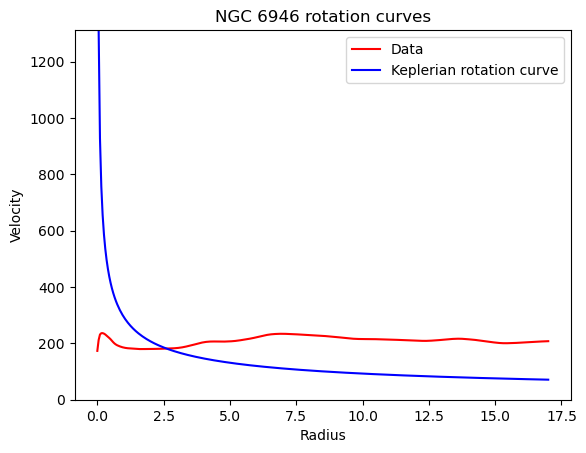

In [1]:
import numpy as np, matplotlib.pyplot as plt
from scipy.constants import G

radius, velocity = np.loadtxt('rotcur.dat',comments='#',unpack=True)

mass = 2e10 * 1.989e30 #kg

keplerian = (((G*mass)/(radius[1:]*3.086e19))**(1/2))/1000 #Keplerian rotation curve in km/s, had to remove zero radius value from text file

newdata = list(zip(radius[1:],keplerian))
np.savetxt('keplerian_curve.txt',newdata)

radiuskep, kep = np.loadtxt('keplerian_curve.txt',unpack=True)

plt.plot(radius,velocity,color='red',label='Data')
plt.plot(radiuskep,kep,color='blue',label='Keplerian rotation curve')
plt.xlabel('Radius')
plt.ylabel('Velocity')
plt.ylim(0,np.max(keplerian))
plt.legend()
plt.title('NGC 6946 rotation curves')
plt.show()

#The Keplerian rotation curve predicts velocity should decrease with radius, while the observational data shows it staying around some approximate
#constant value. This implies additional mass in the galaxy we cannot observe, which is commonly used as proof of dark matter in the universe.

In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 4

<div class='alert alert-warning'>
    <b>Feedback</b> <br>
    plt.show requires parentheses, ie plt.show()
</div>

### Exploring image noise (3 pt)  <font color='red'><b>COURSEWORK</b></font>
   
* Create a two dimensional NumPy array with 200 rows and 300 columns filled with pixel values drawn from the normal distribution ``numpy.random.normal()`` with a mean of 0 and standard deviation 1.0.
* Use ``plt.imshow()`` to plot the image. The figure must be 8 inches wide and 4 inches high.
* Use color map ``jet`` for your image.
* Take a small two dimensional slice (e.g. 30x30 pixels) somewhere in the image and calculate the mean and standard deviation of the pixel values in your slice.
* Are this mean and standard deviation what you expected?
* Plot a histogram of all image values in 50 bins (you will need to ravel/flatten the data first). To not overlap with the previous plot, you probably need to create a new plot ``plt.figure()``. What distribution should you recognise?

**Answer**:

Sample:
Mean = 0.00
Std = 0.98


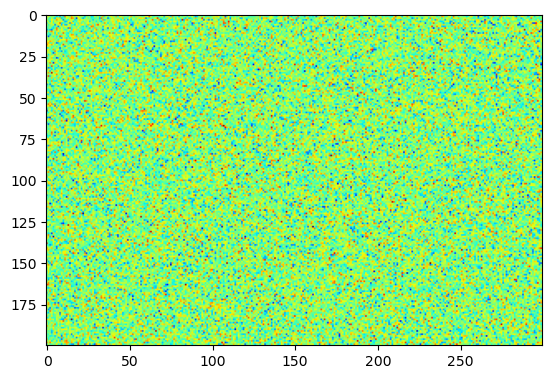

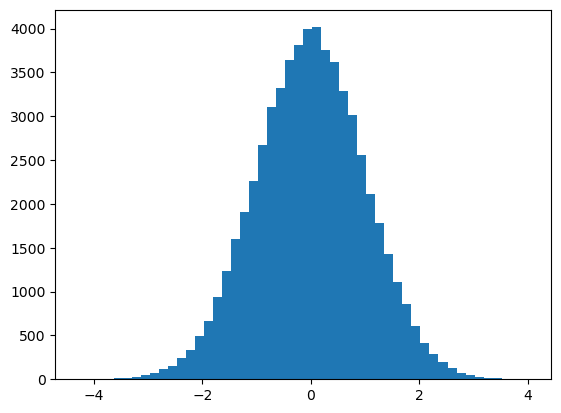

In [4]:
import numpy as np, matplotlib.pyplot as plt, random

arr = np.random.normal(loc=0,scale=1,size=(200,300))

plt.figure()
plt.imshow(arr)
plt.jet()

samplesize = 30
y = random.randint(0,200-samplesize)
x = random.randint(0,300-samplesize)
smallarr = arr[y:y+samplesize,x:x+samplesize]
mean = np.mean(smallarr)
std = np.std(smallarr)
print(f'Sample:')
print(f'Mean = {mean:.2f}')
print(f'Std = {std:.2f}')
#The mean and the standard deviation of the sample both vary very closely around the mean and standard deviation set for the entire image, as expected.

flat = arr.flatten()

plt.figure()
plt.hist(flat,bins=50)
plt.show() #Gaussian distribution

In [5]:
# Leave unaltered
totalpoints += 3
currentpoints += 3

### Extending the Ellipse class (6 pt) <font color='red'><b>COURSEWORK</b></font>

* Copy the code for class ``AstroEllipse`` in the section.
* Extend the class with a method that calculates and returns the area of the ellipse.
* Extend the class with a method that calculates and returns the perimeter of the ellipse (keywords: Ramanujan’s formula for perimeter of ellipse).
* Give an example of the creation of an ellipse with semi major axis equal to 3 and semi minor axis equal to 2 and call the methods for area and perimeter to show what the area and perimeter is for this ellipse.
* Add a method ``__str__()`` which returns a string with the values of the ellipse parameters (center, axes and angle) and demonstrate the method with ``print()``.
* Create a class ``MyCircle`` which inherits from class ``AstroEllipse``. The arguments for its ``__init__()`` function is a center position and a radius.
* Create a plot with three circles with random origins and radii. The circles must have different colors and the  transparency (``alpha=``) must be set to 0.5. Use the ``Axes`` object (Section 5.7) to add the circles to the plot.

**Answers**:

Area = 18.85
Perimeter = 15.87

Ellipse parameters:
Center = (0,0)
Semi major axis = 3
Semi minor axis = 2
Angle = 30


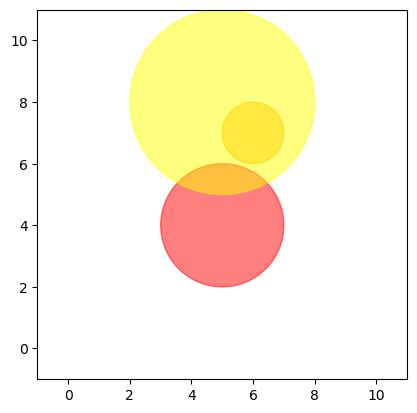

In [6]:
from matplotlib.patches import Ellipse
import math, random, matplotlib.pyplot as plt

class AstroEllipse(Ellipse):
    def __init__(self, xc, yc, semi_major, semi_minor, position_angle, **args):
        assert(semi_major >= semi_minor)
        XY = (xc, yc)
        angle_mpl = position_angle
        height = 2.0*semi_major
        width  = 2.0*semi_minor
        super().__init__(XY, width, height, angle=angle_mpl, **args)
        self.xc = xc
        self.yc = yc
        self.semi_major = semi_major
        self.semi_minor = semi_minor
        self.position_angle = position_angle   #not sure if this is the most effective way to do this but i needed to call the variables in other methods
    def area(self):
        #calculates area of input ellipse
        area = self.semi_major * self.semi_minor * math.pi
        return area
    def perimeter(self):
        #calculates perimeter of input ellipse using Ramanujan's formula
        perimeter = math.pi*(3*(self.semi_major+self.semi_minor)-((3*self.semi_major+self.semi_minor)*(self.semi_major+3*self.semi_minor))**(1/2))
        return perimeter
    def __str__(self):
        #prints string about input ellipse
        s = f'Ellipse parameters:\nCenter = ({self.xc},{self.yc})\nSemi major axis = {self.semi_major}\nSemi minor axis = {self.semi_minor}\nAngle = {self.position_angle}'
        return s
        
ellipse = AstroEllipse(0,0,3,2,30) #random center and angle
print(f'Area = {ellipse.area():.2f}')
print(f'Perimeter = {ellipse.perimeter():.2f}')
print()
print(ellipse)

class MyCircle(AstroEllipse):
    #creates circle based on class AstroEllipse
    def __init__(self,x,y,radius,**args):
        super().__init__(x,y,radius,radius,0,**args)

def coord():
    #random coordinates to generate truly random circles
    a = random.randint(2,8)
    b = random.randint(1,3)
    return a, b

circle1 = MyCircle(coord()[0],coord()[0],coord()[1],color='red',alpha=0.5)
circle2 = MyCircle(coord()[0],coord()[0],coord()[1],color='orange',alpha=0.5)
circle3 = MyCircle(coord()[0],coord()[0],coord()[1],color='yellow',alpha=0.5)

fig = plt.figure()
frame = fig.add_subplot(1,1,1,aspect=1)
frame.add_patch(circle1)
frame.add_patch(circle2)
frame.add_patch(circle3)
frame.set_xlim(-1,11)
frame.set_ylim(-1,11)
plt.show()

In [7]:
# Leave unaltered
totalpoints += 6
currentpoints += 6

### Plotting Bessel's function (3 pt) <font color='red'><b>COURSEWORK</b></font>
   
The differential equation of Bessel is:

$$x^2\ \frac{d^2y}{dx^2}+x\ \frac{dy}{dx}+(x^2-a^2)y=0$$

Solutions of this equation are called Bessel functions of the first kind of real order ``a``.
Bessel functions are especially important for problems of wave propagation and static 
potentials and in solutions to the radial Schrodinger equation in quantum mechanics. 

Module ``special`` in package SciPy provides Bessel functions with the import statement:

```python
from scipy.special import jv
```

Write code that plots a solution of Bessel's differential equation for ``a=1,2,3`` and ``a=4`` on the interval ``x=[0,10]``in a mosaic of 2x2 plots. A Bessel function has arguments: ``jv(a, x)`` 

<font color='red'>Note: Object Oriented Plotting is required, or 1.0pt will be deducted.</font>

* Annotate your plot with a title and labels for the $x$- and $y$ axis. 
* Add a legend with labels for all curves.
* Include code that saves your figure to a file with base name ``bessel`` as a transparent PNG file.
* Attach the figure (PNG file) in the notebook.

**Code and figure**:

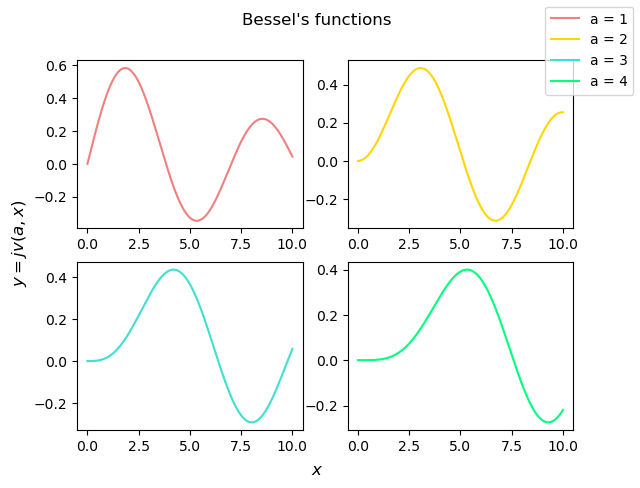

In [8]:
from scipy.special import jv
from matplotlib.pyplot import figure, show
import numpy as np

x = np.linspace(0,10,1000)
y1 = jv(1,x)
y2 = jv(2,x)
y3 = jv(3,x)
y4 = jv(4,x)

fig = figure()
frame1 = fig.add_subplot(2,2,1)
frame2 = fig.add_subplot(2,2,2)
frame3 = fig.add_subplot(2,2,3)
frame4 = fig.add_subplot(2,2,4)
frame1.plot(x,y1,label='a = 1',color='lightcoral')
frame2.plot(x,y2,label='a = 2',color='gold')
frame3.plot(x,y3,label='a = 3',color='turquoise')
frame4.plot(x,y4,label='a = 4',color='springgreen')
fig.supxlabel(r'$x$')
fig.supylabel(r'$y=jv(a,x)$')
fig.suptitle('Bessel\'s functions')
fig.legend()
show()

fig.savefig('bessel.png',transparent=True)

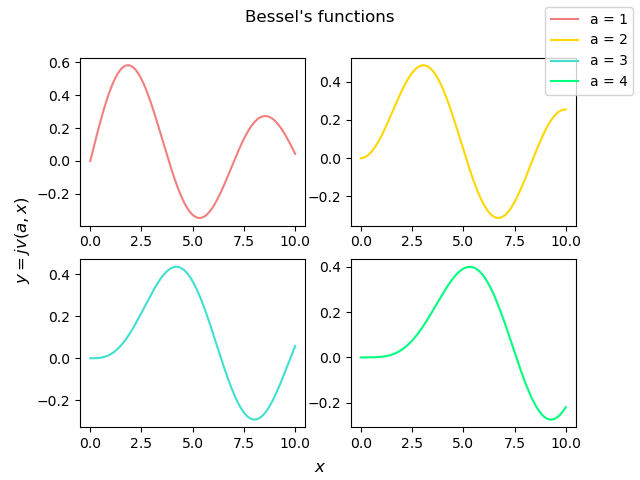

In [9]:
# Leave unaltered
totalpoints += 3
currentpoints += 3

### Matplotlib, the right way (2 pt)  <font color='red'><b>HOMEWORK</b></font>

The following table contains the measurements of distances and velocities, including their uncertainties, for a small sample of galaxies. The table is given in the form of a Python list.

From your previous coursework, you have done chi-squared fitting to fit the following data without uncertainties. If considering the uncertainties during the fitting process, the slope of a best fit line through the data gives a value for the Hubble constant.

$$H_0 = 67.8 (km/s)/Mpc$$

```
    d(Mpc)    v(km/s)    error in d    error in v
    ==============================================
    18.49      2094.75    0.3           100
    35.48      2320.87    2.2           120
    ........
```
```python
    data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
```

<font color='red'>In this question, you have to use the OO interface of Matplotlib to create your plot, or 1.0pt will be deducted.</font>

* Use slicing syntax to unpack ``data`` into separate variables for distance and velocity, as well as their corresponding errors.
* Create a plot for this data. Add error bars with method `errorbar() <matplotlib.axes.Axes.errorbar>`
* Plot also a line which represents the Hubble relation between distance and velocity  as a line through the origin, with a slope equal to $H_0$
* Add the value of $H_0$ to the legend using LaTex math mode
  
**Script and plot**:

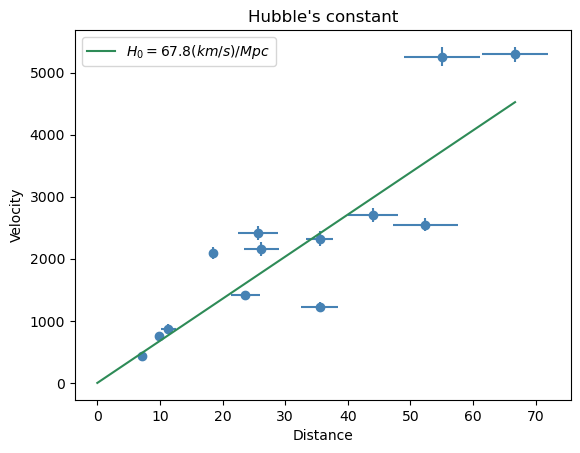

In [10]:
import numpy as np
from matplotlib.pyplot import figure, show

data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]

#data unpacking
distance = np.asarray(data[::4])
dis_error = np.asarray(data[2::4])
velocity = np.asarray(data[1::4])
vel_error = np.asarray(data[3::4])

H0 = 67.8
dline = np.linspace(0,max(distance),100) #to give us a plot going through the origin

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.scatter(distance,velocity,color='steelblue')
frame.errorbar(distance,velocity,vel_error,dis_error,fmt='none',color='steelblue')
frame.plot(dline,H0*dline,color='seagreen',label=r'$H_0=67.8(km/s)/Mpc$')
frame.legend()
frame.set_xlabel(r'Distance')
frame.set_ylabel(r'Velocity')
frame.set_title('Hubble\'s constant')
show()

In [11]:
# Leave unaltered
totalpoints += 2
currentpoints += 2

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [12]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 18. Student score: 18.  Task Grade = 10.0
